#Assignment-1



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [3]:
print(X.head())
print(X.info())
print(X.describe())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    

In [7]:
print(X.isnull().sum())


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


In [8]:
X = X.fillna(X.mean())

In [9]:
for col in X.columns:
    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    X[col] = np.where(X[col] > upper, upper, X[col])
    X[col] = np.where(X[col] < lower, lower, X[col])

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
mean = X_train.mean()
std = X_train.std()

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [12]:
n_features = X_train.shape[1]

weights = np.zeros(n_features)
bias = 0

In [13]:
def compute_cost(X, y, weights, bias):
    n = len(y)
    y_pred = np.dot(X, weights) + bias
    cost = (1/(2*n)) * np.sum((y_pred - y)**2)
    return cost

In [14]:
def gradient_descent(X, y, weights, bias, lr, iterations):
    n = len(y)
    costs = []

    for i in range(iterations):
        y_pred = np.dot(X, weights) + bias

        dw = (1/n) * np.dot(X.T, (y_pred - y))
        db = (1/n) * np.sum(y_pred - y)

        weights = weights - lr * dw
        bias = bias - lr * db

        cost = compute_cost(X, y, weights, bias)
        costs.append(cost)

    return weights, bias, costs

In [15]:
learning_rates = [0.01, 0.03, 0.1]

results = {}

for lr in learning_rates:
    w, b, cost = gradient_descent(X_train, y_train, np.zeros(n_features), 0, lr, 1000)
    results[lr] = cost

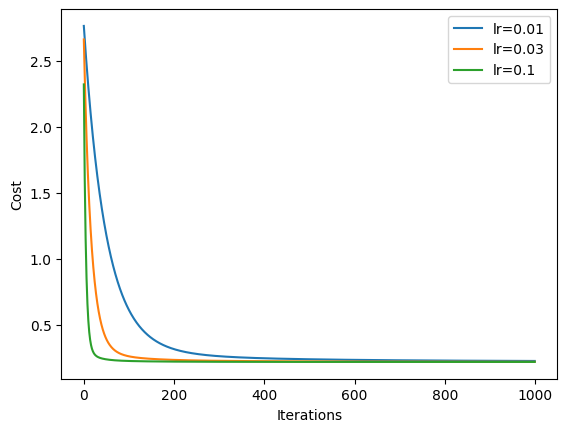

In [16]:
for lr in learning_rates:
    plt.plot(results[lr], label=f"lr={lr}")

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()
plt.show()

In [17]:
def predict(X, weights, bias):
    return np.dot(X, weights) + bias

y_pred = predict(X_test, w, b)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.5040300133403874
MSE: 0.46388221422754355
RMSE: 0.6810889914156179
R2: 0.6460019566942667


In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_sklearn = model.predict(X_test)

print("Sklearn R2:", r2_score(y_test, y_pred_sklearn))

Sklearn R2: 0.6460366194146243


In [20]:
def sgd(X, y, lr, iterations):
    n, m = X.shape
    w = np.zeros(m)
    b = 0

    for _ in range(iterations):
        for i in range(n):
            idx = np.random.randint(n)
            xi = X.iloc[idx]
            yi = y.iloc[idx]

            pred = np.dot(xi, w) + b
            error = pred - yi

            w -= lr * error * xi
            b -= lr * error

    return w, b

#Assignment-2

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [26]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


<Axes: >

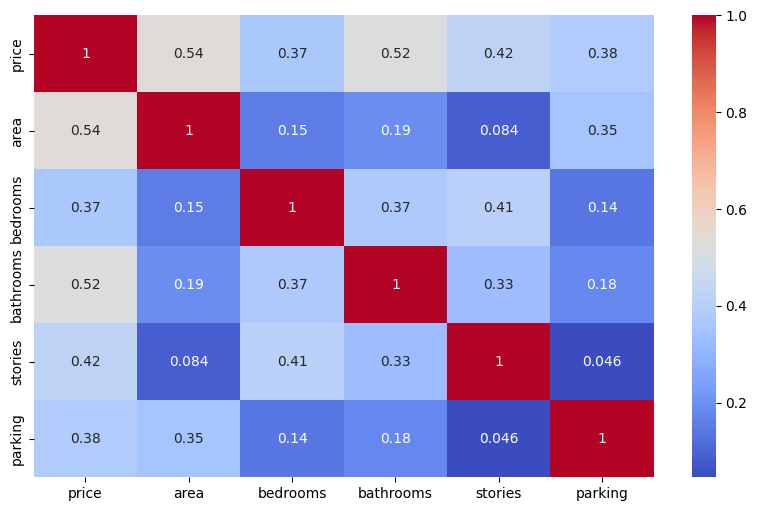

In [30]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

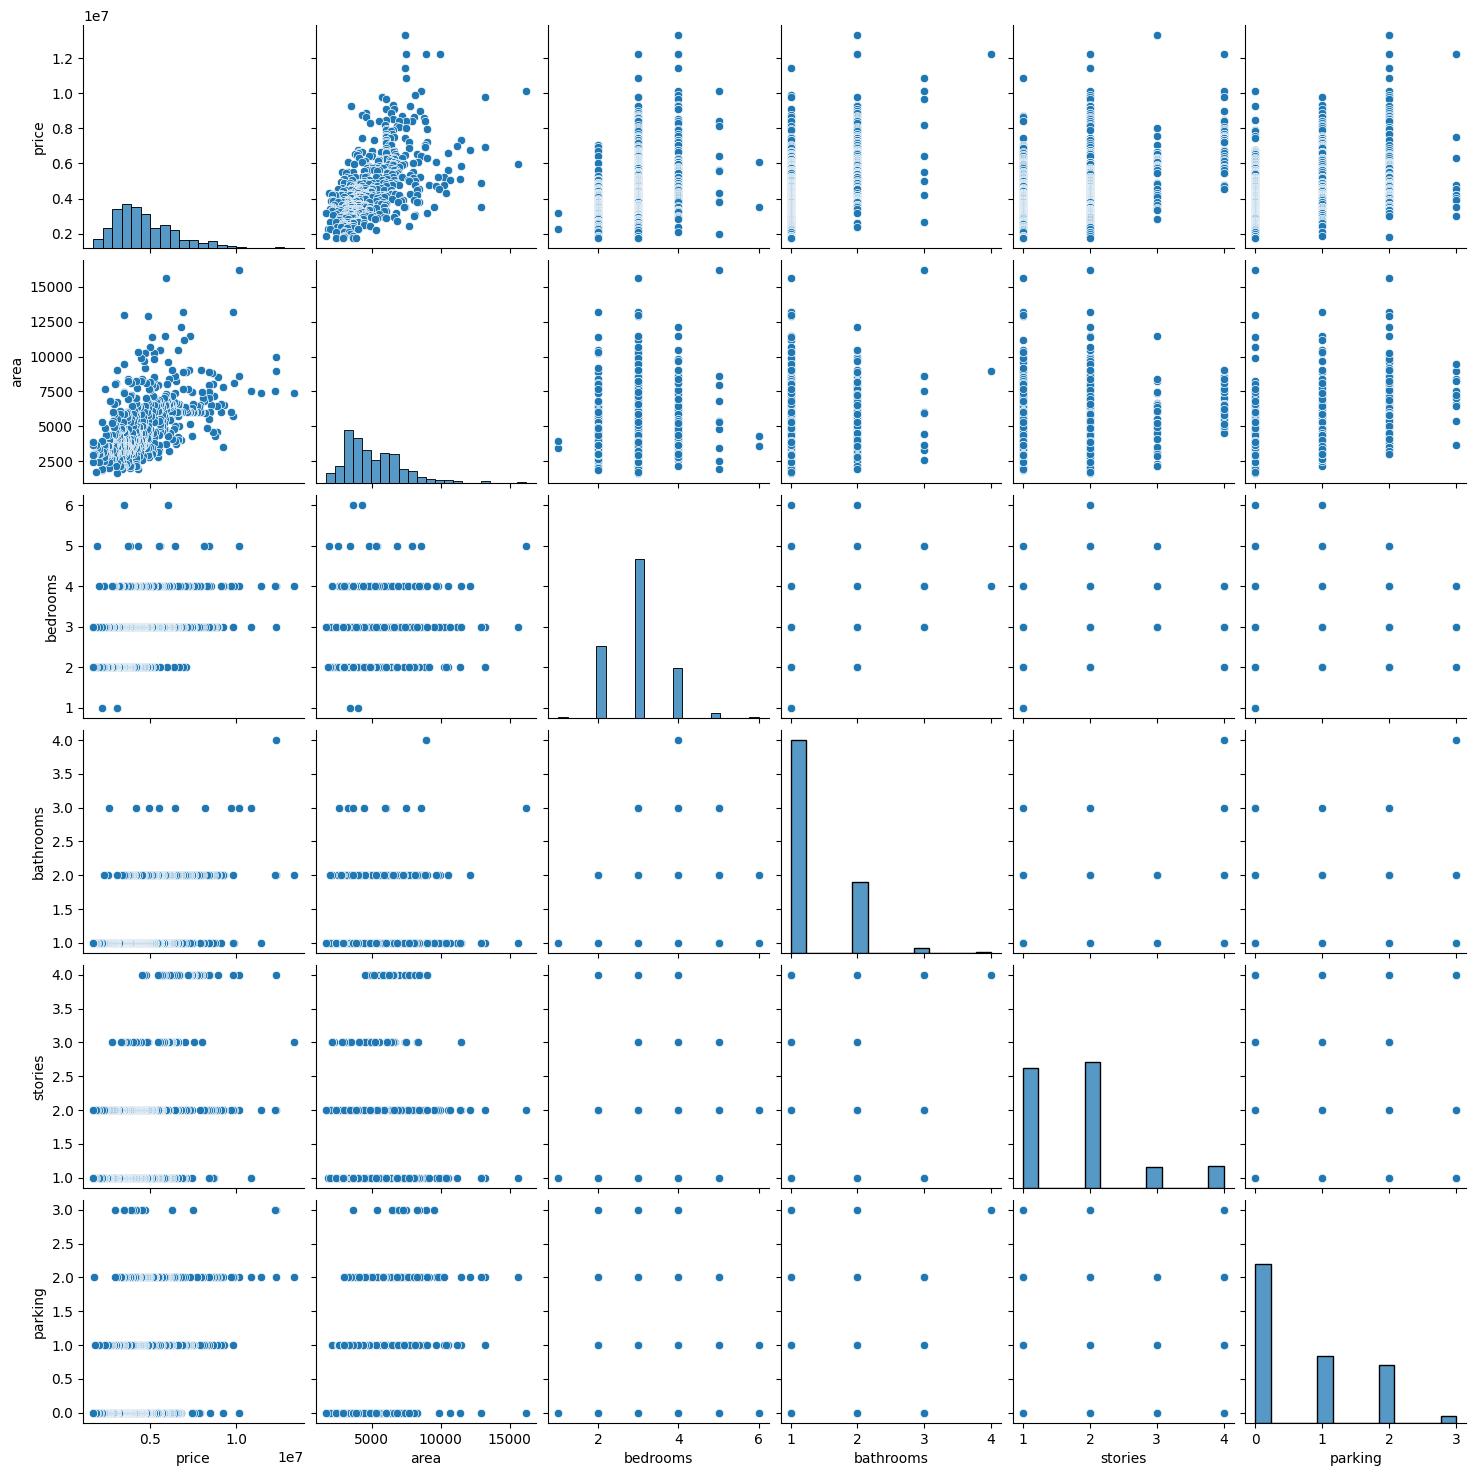

In [29]:
sns.pairplot(df)

In [31]:
df = df.fillna(df.mean(numeric_only=True))

In [32]:
df = pd.get_dummies(df, drop_first=True)

In [34]:
X = df.drop("price", axis=1)
y = df["price"]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
X_train_numeric = X_train.astype(float)
vif_data["VIF"] = [variance_inflation_factor(X_train_numeric.values, i) for i in range(len(X_train_numeric.columns))]

print(vif_data)

                            feature        VIF
0                              area   8.030463
1                          bedrooms  17.255074
2                         bathrooms  10.118570
3                           stories   7.990720
4                           parking   1.988904
5                      mainroad_yes   6.957378
6                     guestroom_yes   1.535238
7                      basement_yes   2.116071
8               hotwaterheating_yes   1.093303
9               airconditioning_yes   1.814088
10                     prefarea_yes   1.487112
11  furnishingstatus_semi-furnished   2.437430
12     furnishingstatus_unfurnished   2.009241


In [39]:
X_train = X_train.drop("bedrooms", axis=1)
X_test = X_test.drop("bedrooms", axis=1)

In [41]:
vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
X_train_numeric = X_train.astype(float) # Convert boolean columns to numeric
vif_data["VIF"] = [variance_inflation_factor(X_train_numeric.values, i) for i in range(len(X_train_numeric.columns))]

print(vif_data)

                            feature       VIF
0                              area  7.590323
1                         bathrooms  8.491519
2                           stories  6.343188
3                           parking  1.986390
4                      mainroad_yes  6.856384
5                     guestroom_yes  1.528062
6                      basement_yes  1.998133
7               hotwaterheating_yes  1.093012
8               airconditioning_yes  1.811070
9                      prefarea_yes  1.486170
10  furnishingstatus_semi-furnished  2.283077
11     furnishingstatus_unfurnished  1.849360


In [42]:
from sklearn.linear_model import LinearRegression

model_simple = LinearRegression()
model_simple.fit(X_train[["area"]], y_train)

y_pred_simple = model_simple.predict(X_test[["area"]])

In [43]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

print("Simple Model:", evaluate(y_test, y_pred_simple))
print("Multiple Model:", evaluate(y_test, y_pred_multi))

Simple Model: (1474748.1337969352, np.float64(1917103.7021424233), 0.27287851871974644)
Multiple Model: (977501.7042261685, np.float64(1329747.4110348267), 0.6501724002298137)


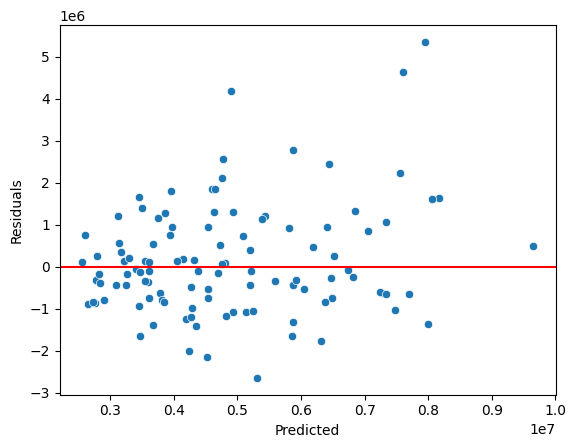

In [45]:
residuals = y_test - y_pred_multi

sns.scatterplot(x=y_pred_multi, y=residuals)
plt.axhline(y=0, color='r')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

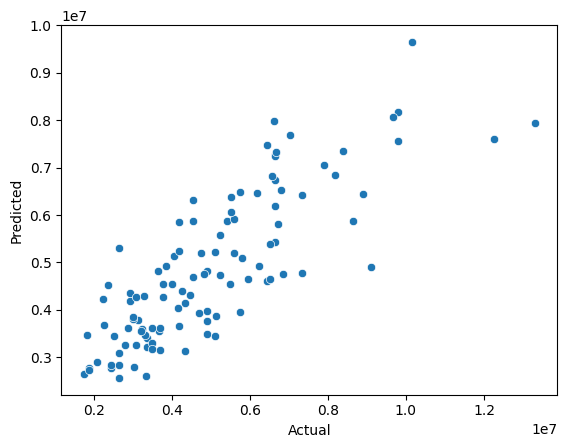

In [46]:
sns.scatterplot(x=y_test, y=y_pred_multi)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

### 1. Which features influence price?

Features like area, location, number of bedrooms, and bathrooms usually have the highest impact on house prices because they directly affect property value.

### 2. Which features cause multicollinearity?

Highly related features like area and number of rooms or bedrooms and bathrooms can cause multicollinearity. This is identified using high VIF values.

### Highly related features like area and number of rooms or bedrooms and bathrooms can cause multicollinearity. This is identified using high VIF values.

Feature engineering helped by:

converting categorical variables into numeric form

removing missing values

reducing multicollinearity

This resulted in better accuracy and improved R² score.

# Assignment-3

In [48]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
df = pd.read_csv("advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [50]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Baseline R2:", r2_score(y_test, y_pred))

Baseline R2: 0.9059011844150826


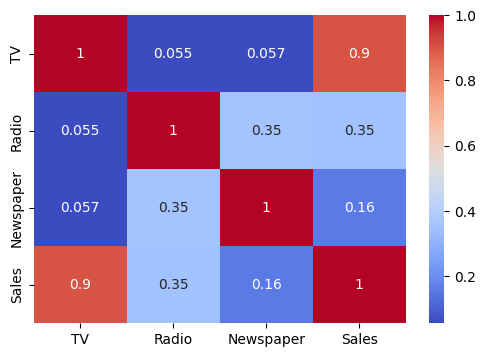

In [52]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [53]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

     feature       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245


In [54]:
X_new = X.drop("Newspaper", axis=1)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("New R2:", r2_score(y_test, y_pred2))

New R2: 0.9078797802624651


In [56]:
print("Before:", r2_score(y_test, y_pred))
print("After:", r2_score(y_test, y_pred2))

Before: 0.9059011844150826
After: 0.9078797802624651


### 1. Why multicollinearity is harmful?

Multicollinearity makes it difficult to understand the impact of individual features because features become highly dependent on each other. This reduces model reliability and interpretability.

### 2. How it affects coefficients?



When multicollinearity is present:

|- coefficients become unstable

|- small data changes can cause large coefficient changes

|- signs of coefficients may even flip

### 3. How removing features improved model?

By removing highly correlated or less useful features (like Newspaper), the model becomes more stable and easier to interpret. It may also slightly improve performance by reducing noise.

# Assignment-4

In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [59]:
X = df.drop("price", axis=1)
y = df["price"]

X = pd.get_dummies(X, drop_first=True)

X = X.fillna(X.mean())

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [61]:
residuals = y_test - y_pred

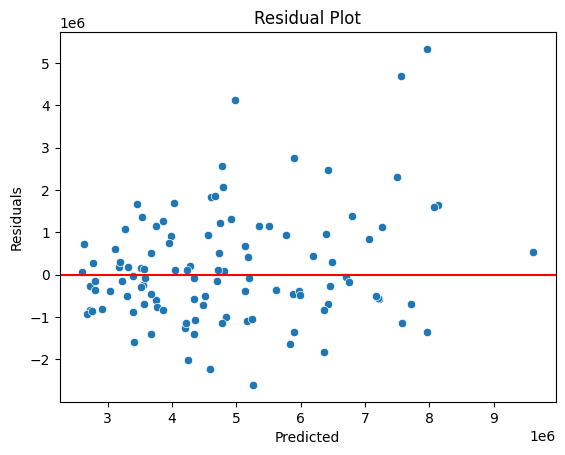

In [62]:
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

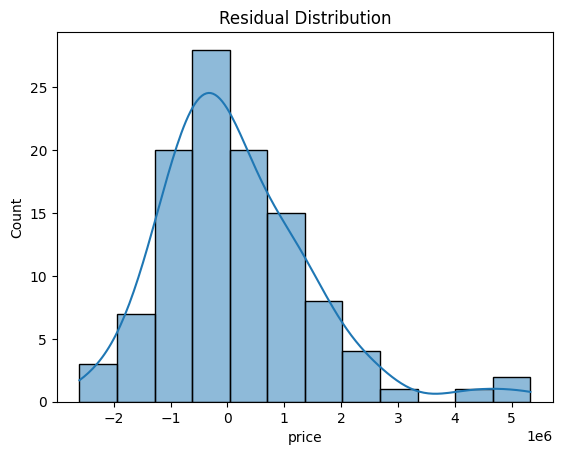

In [63]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

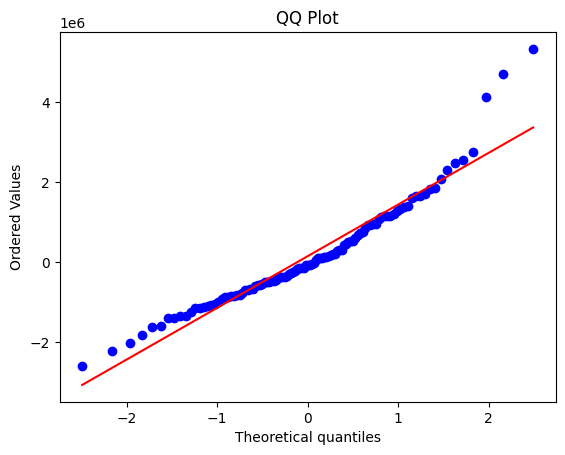

In [64]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()

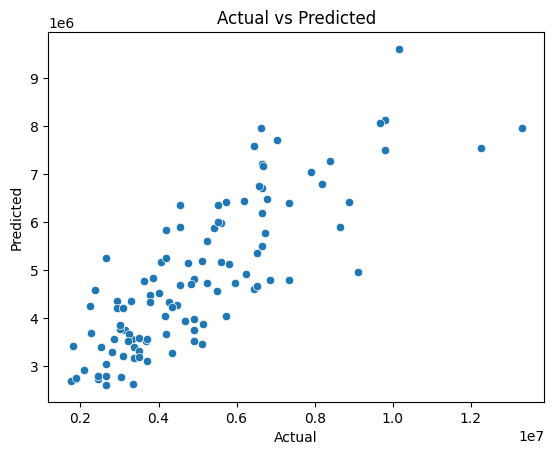

In [65]:
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

### 1. Are residuals normally distributed?

The histogram and QQ plot show that residuals are approximately normally distributed, although slight deviations may exist. Overall, the assumption is reasonably satisfied.

### 2. Is there heteroscedasticity?

From the residual plot, if the spread of residuals is not constant and forms a pattern (like funnel shape), then heteroscedasticity is present. If the points are randomly scattered, then the assumption is satisfied.

### 3. How to fix violations?

If assumptions are violated:

Apply transformation (log, sqrt) on target variable

Remove outliers

Use regularization techniques

Use different models like Random Forest if linear assumption fails

## Residual plot shows mostly random distribution, indicating linearity assumption is satisfied.

# ***Assignment-5***

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [67]:
from sklearn.datasets import load_diabetes

data = load_diabetes()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [70]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [71]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [73]:
print("Linear:", evaluate(y_test, y_pred_lr))
print("Ridge:", evaluate(y_test, y_pred_ridge))
print("Lasso:", evaluate(y_test, y_pred_lasso))

Linear: (42.79409467959994, np.float64(53.85344583676593), 0.4526027629719195)
Ridge: (46.13885766697452, np.float64(55.47446204180109), 0.41915292635986545)
Lasso: (42.85442771664998, np.float64(52.897953506442185), 0.4718547867276227)


### 1. Which model performs best?

In most cases, Ridge Regression performs slightly better than Linear Regression because it reduces overfitting. Lasso may also perform well but can sometimes reduce accuracy if it removes too many features.

### 2. Why does Ridge reduce overfitting?

Ridge Regression adds a penalty (L2) to the loss function, which shrinks the coefficients. This prevents the model from relying too much on any single feature, making it more stable and reducing overfitting.

### 3. Which features were removed by Lasso?

Lasso Regression sets some coefficients to zero. These features are effectively removed from the model. You can check them using:
image.png

Any coefficient equal to 0 means that feature is removed.

In [74]:
pd.Series(lasso.coef_, index=X.columns)

,0
age,0.000000
sex,-152.664779
bmi,552.697775
bp,303.365158
s1,-81.365007
s2,-0.000000
s3,-229.255776
s4,0.000000
s5,447.919525
s6,29.642617


# Assignment-6

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [78]:
print(df.isnull().sum())

df = df.fillna(df.mean(numeric_only=True))

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [79]:
df = pd.get_dummies(df, drop_first=True)

In [80]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [82]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [83]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

params = {"alpha": [0.01, 0.1, 1, 10]}

grid = GridSearchCV(ridge, params, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 4193.585298299822
RMSE: 5800.434215796178
R2: 0.7832830144988215


In [85]:
import joblib

joblib.dump(best_model, "insurance_model.pkl")

['insurance_model.pkl']

# Assignment-7

### Salary Prediction using Linear Regression

In [112]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [113]:
df = pd.read_csv("Salary_Data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [114]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


In [115]:
df = df.drop("Job Title", axis=1)

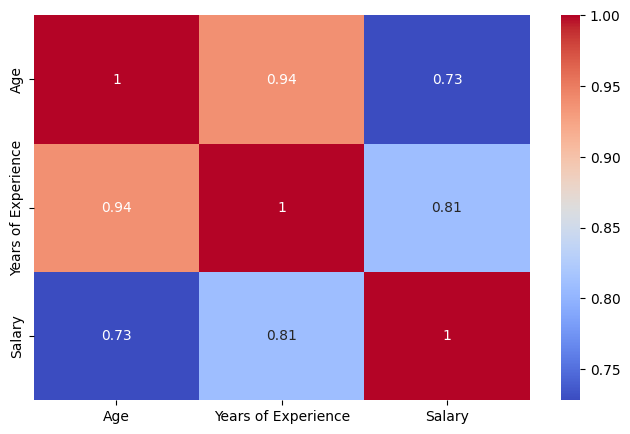

In [116]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

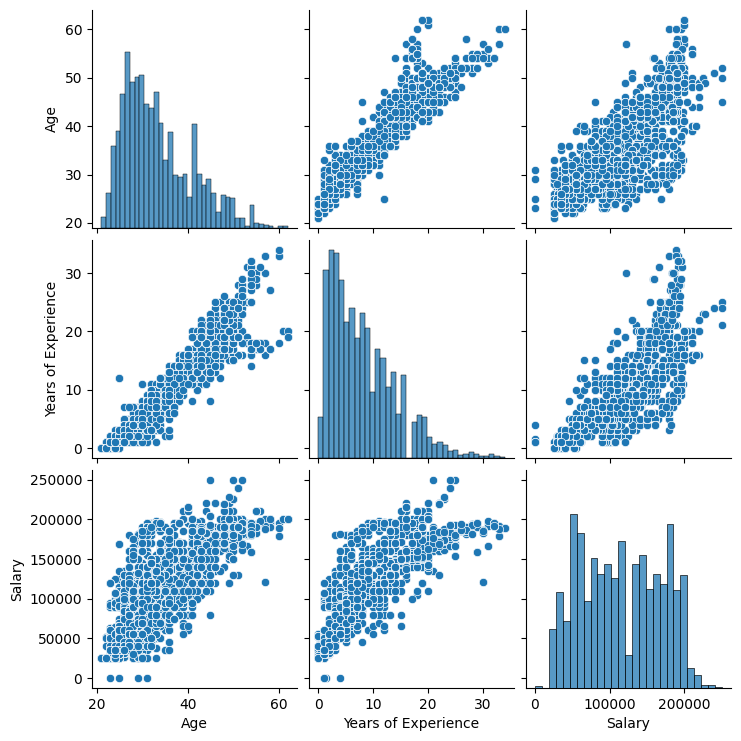

In [117]:
sns.pairplot(df)
plt.show()

In [118]:
df = df.fillna(df.mean(numeric_only=True))

In [119]:
df = pd.get_dummies(df, drop_first=True)

In [120]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

In [121]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [122]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
X_train_numeric = X_train.astype(float) # Convert boolean columns to numeric
vif_data["VIF"] = [variance_inflation_factor(X_train_numeric.values, i) for i in range(len(X_train_numeric.columns))]

print(vif_data)

                             feature        VIF
0                                Age  22.627730
1                Years of Experience   8.932940
2                        Gender_Male   2.315188
3                       Gender_Other   1.052838
4  Education Level_Bachelor's Degree   3.930329
5        Education Level_High School   1.656090
6           Education Level_Master's   1.390049
7    Education Level_Master's Degree   3.306809
8                Education Level_PhD   3.575632
9                Education Level_phD   1.001236


In [123]:
X_train = X_train.drop("Age", axis=1)
X_test = X_test.drop("Age", axis=1)

In [124]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
X_train_numeric = X_train.astype(float) # Convert boolean columns to numeric
vif_data["VIF"] = [variance_inflation_factor(X_train_numeric.values, i) for i in range(len(X_train_numeric.columns))]

print(vif_data)

                             feature       VIF
0                Years of Experience  4.105175
1                        Gender_Male  2.027467
2                       Gender_Other  1.050516
3  Education Level_Bachelor's Degree  1.642341
4        Education Level_High School  1.072929
5           Education Level_Master's  1.142627
6    Education Level_Master's Degree  1.868483
7                Education Level_PhD  2.588032
8                Education Level_phD  1.000827


In [125]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [126]:
y_pred = model.predict(X_test)

In [127]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 18736.50186421656
MSE: 625417650.1952503
RMSE: 25008.351608917576
R2: 0.7658216731359605


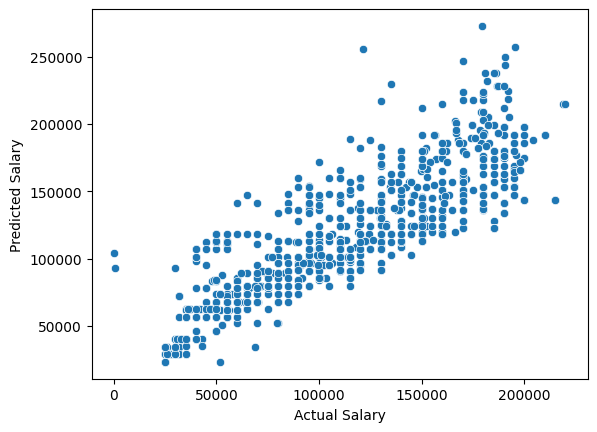

In [128]:
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.show()

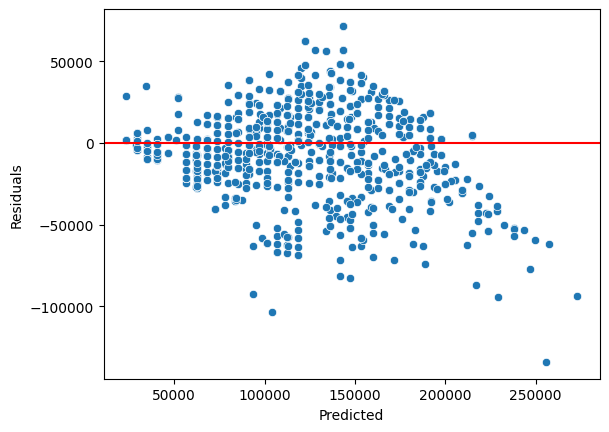

In [129]:
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

### 🔹 Feature Engineering

Categorical variables like education, location, and skills were converted into numerical form using one-hot encoding.

### 🔹 Multicollinearity

VIF was used to detect multicollinearity. Features with high VIF were removed to improve model stability.

### 🔹 Model Performance

The model was evaluated using MAE, MSE, RMSE, and R² score. These metrics help understand prediction accuracy and error.

### 🔹 Observations

Experience has strong impact on salary

Education and skills also influence salary

Location may affect salary due to cost of living

In [130]:
pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
}).head()

,Actual,Predicted
2794,156486.0,191922.658743
2233,140000.0,118524.798181
5559,80000.0,73775.985290
6355,40000.0,40574.156352
263,50000.0,107049.112715
